In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import PowerTransformer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(tmin=-0.5, tmax=1.5, resample=None, fmin=0.1, fmax=None)
dataset = BNCI2014009()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.


<RawArray | 18 x 50184 (196.0 s), ~6.9 MB, data loaded>

In [4]:
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,-0.500 – 1.500 sec
Baseline,off


In [5]:
n_freqs = 32
freqs = np.linspace(1,32,n_freqs)
n_cycles = 0.8*freqs
sfreq=64

epochs_tfr = tfr_morlet(
    epochs, freqs, n_cycles, return_itc=False, average=False,
    output='complex', verbose=True, n_jobs=-1,
                        decim=int(epochs.info['sfreq']//sfreq))
epochs_tfr.data = np.real(epochs_tfr.data)
epochs_tfr.apply_baseline((0,1.2), mode='zscore')
epochs_tfr.crop(0, 1.2)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 out of  16 | elapsed:    5.1s remaining:    3.9s
[Parallel(n_jobs=-1)]: Done  13 out of  16 | elapsed:    5.7s remaining:    1.3s


Not setting metadata
Applying baseline correction (mode: zscore)


[Parallel(n_jobs=-1)]: Done  16 out of  16 | elapsed:    6.0s finished


<EpochsTFR | time : [0.000000, 1.203125], freq : [1.000000, 32.000000], epochs : 576, channels : 16, ~175.5 MB>

No baseline correction applied
No baseline correction applied
No baseline correction applied


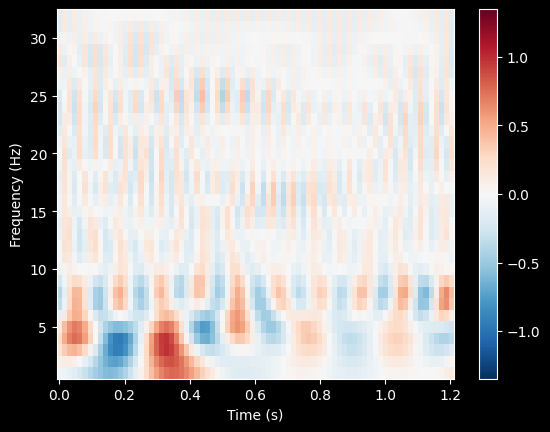

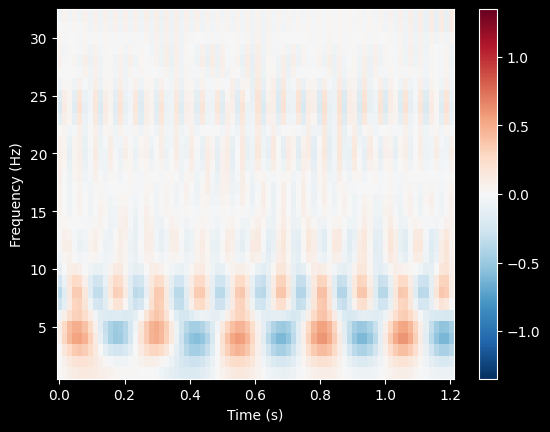

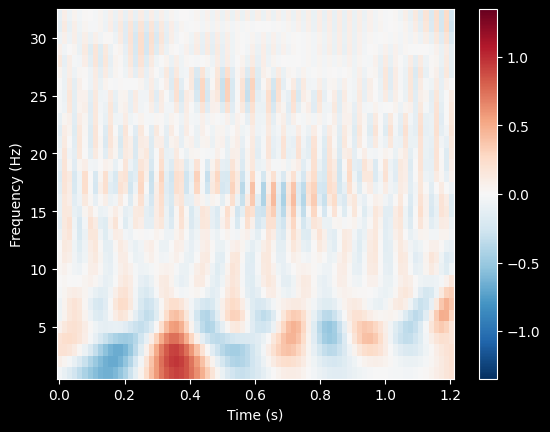

In [6]:
from mne import combine_evoked

plt.style.use('dark_background')


target = epochs_tfr['Target'].average()
non_target = epochs_tfr['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])

vmax = np.max(np.abs(target.data))
tfr_args=dict(picks=['Cz'],show=False,vmin=-vmax,vmax=vmax)

_ = target.plot(**tfr_args)
_ = non_target.plot(**tfr_args)
_ = contrast.plot(**tfr_args)

In [7]:
epochs_tfr.data = np.real(epochs_tfr.data)

In [8]:
split = len(epochs)//2
epochs_train = epochs_tfr[:split]
epochs_test = epochs_tfr[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [9]:
import tensorly as tl
tl.set_backend('cupy')


In [10]:
import tensorly.decomposition
import tensorly.tenalg
X_train = tl.tensor(epochs_train.data, dtype=epochs_train.data.dtype)
y_train = labels_train
X_test = tl.tensor(epochs_test.data, dtype=epochs_train.data.dtype)
y_test = labels_test

In [19]:
import cupy
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from hoda.hoda import BTTDA

hoda_lda = Pipeline([
        ('bttda', BTTDA(
            n_blocks=4,
            verbose=True,
            keep_train_score=True,
            hoda_params=dict(
                rank=None,
                max_iter=64,
                tol=1e-3,
                init ='mlsvd',
                verbose=True,
                shrinkage=('lw','lw','lw'),
                toeplitz=(2,),
                taper=False,
                solver='diff',
                keep_train_info=True,
            )
        )),
        ('lda', LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')),
        #('svm', SVC(kernel='rbf', C=1e-3)),

])

hoda_lda.fit(X_train,y_train)

Fitting block 1/4...


  0%|          | 0/64 [00:00<?, ?it/s]

Fit tucker model of rank [2, 4, 13]

Fitting block 2/4...


  0%|          | 0/64 [00:00<?, ?it/s]

Fit tucker model of rank [2, 4, 13]

Fitting block 3/4...


  0%|          | 0/64 [00:00<?, ?it/s]

Fit tucker model of rank [2, 4, 13]

Fitting block 4/4...


  0%|          | 0/64 [00:00<?, ?it/s]

Fit tucker model of rank [2, 4, 13]



Pipeline(steps=[('bttda',
                 BTTDA(hoda_params={'init': 'mlsvd', 'keep_train_info': True,
                                    'max_iter': 64, 'rank': None,
                                    'shrinkage': ('lw', 'lw', 'lw'),
                                    'solver': 'diff', 'taper': False,
                                    'toeplitz': (2,), 'tol': 0.001,
                                    'verbose': True},
                       keep_train_score=True, n_blocks=4, verbose=True)),
                ('lda',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])

<AxesSubplot: xlabel='score', ylabel='Count'>

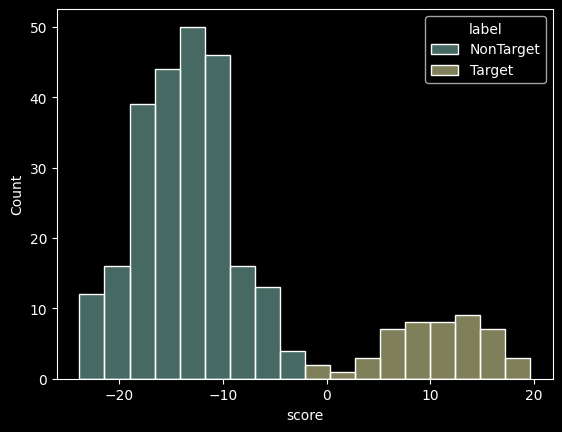

In [20]:
import pandas as pd

train_scores = cupy.asnumpy(hoda_lda.decision_function(X_train))
df = pd.DataFrame(dict(score=cupy.asnumpy(train_scores),label=labels_train))
sns.histplot(data=df, x='score', hue='label')

In [21]:
roc_auc_score(y_train,train_scores)

1.0

<AxesSubplot: xlabel='score', ylabel='Count'>

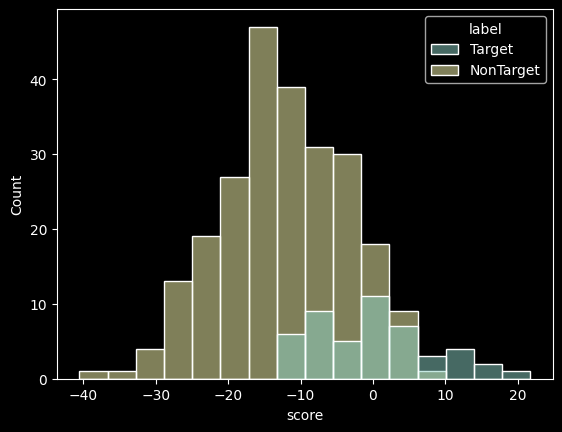

In [22]:
import pandas as pd

test_scores = cupy.asnumpy(hoda_lda.decision_function(X_test))
df = pd.DataFrame(dict(score=cupy.asnumpy(test_scores),label=labels_test))
sns.histplot(data=df, x='score', hue='label')

In [23]:
roc_auc_score(y_test,test_scores)

0.8496527777777778